# Ánalise Exploratória dos dados

## Importação de módulos

In [53]:
import matplotlib.pyplot as plt
from google.colab import drive
import os, unicodedata, re
import seaborn as sns
import pandas as pd
import numpy as np

## Montar o Google Drive para acessar os arquivos

In [54]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Leitura e transformação para DataFrame pandas

In [55]:
def normalize_column(col):
    col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
    col = col.lower()
    col = re.sub(r'(?<!^)(?=[A-Z])', '_', col)
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_')

In [56]:
dirpath = '/content/drive/My Drive/supervised-learning-studies'
filename = 'dados_ConcretoYER_geral.csv'
file_path = os.path.join(dirpath, filename)

# O arquivo deve ser lido de um csv devido ao formato das casas decimais, que usam ponto ao invés de vírgula. O Excel, por exemplo, não consegue ler esse formato corretamente.
df = pd.read_csv(file_path)
dim_before = df.shape[0]
df.dropna(inplace=True)
df.drop_duplicates(inplace=True, keep='first')
dim_after = df.shape[0]
print(f"Dimensão antes da limpeza: {dim_before}")
print(f"Dimensão depois da limpeza: {dim_after}")
df.columns = [normalize_column(c) for c in df.columns]

Dimensão antes da limpeza: 1030
Dimensão depois da limpeza: 1005


In [57]:
df.columns

Index(['cimento', 'escoriadealtoforno', 'cinzasvolantes', 'agua',
       'superplastificante', 'agregadogrosso', 'agregadofino', 'idade',
       'resistencia'],
      dtype='object')

## Inpeção inicial das colunas

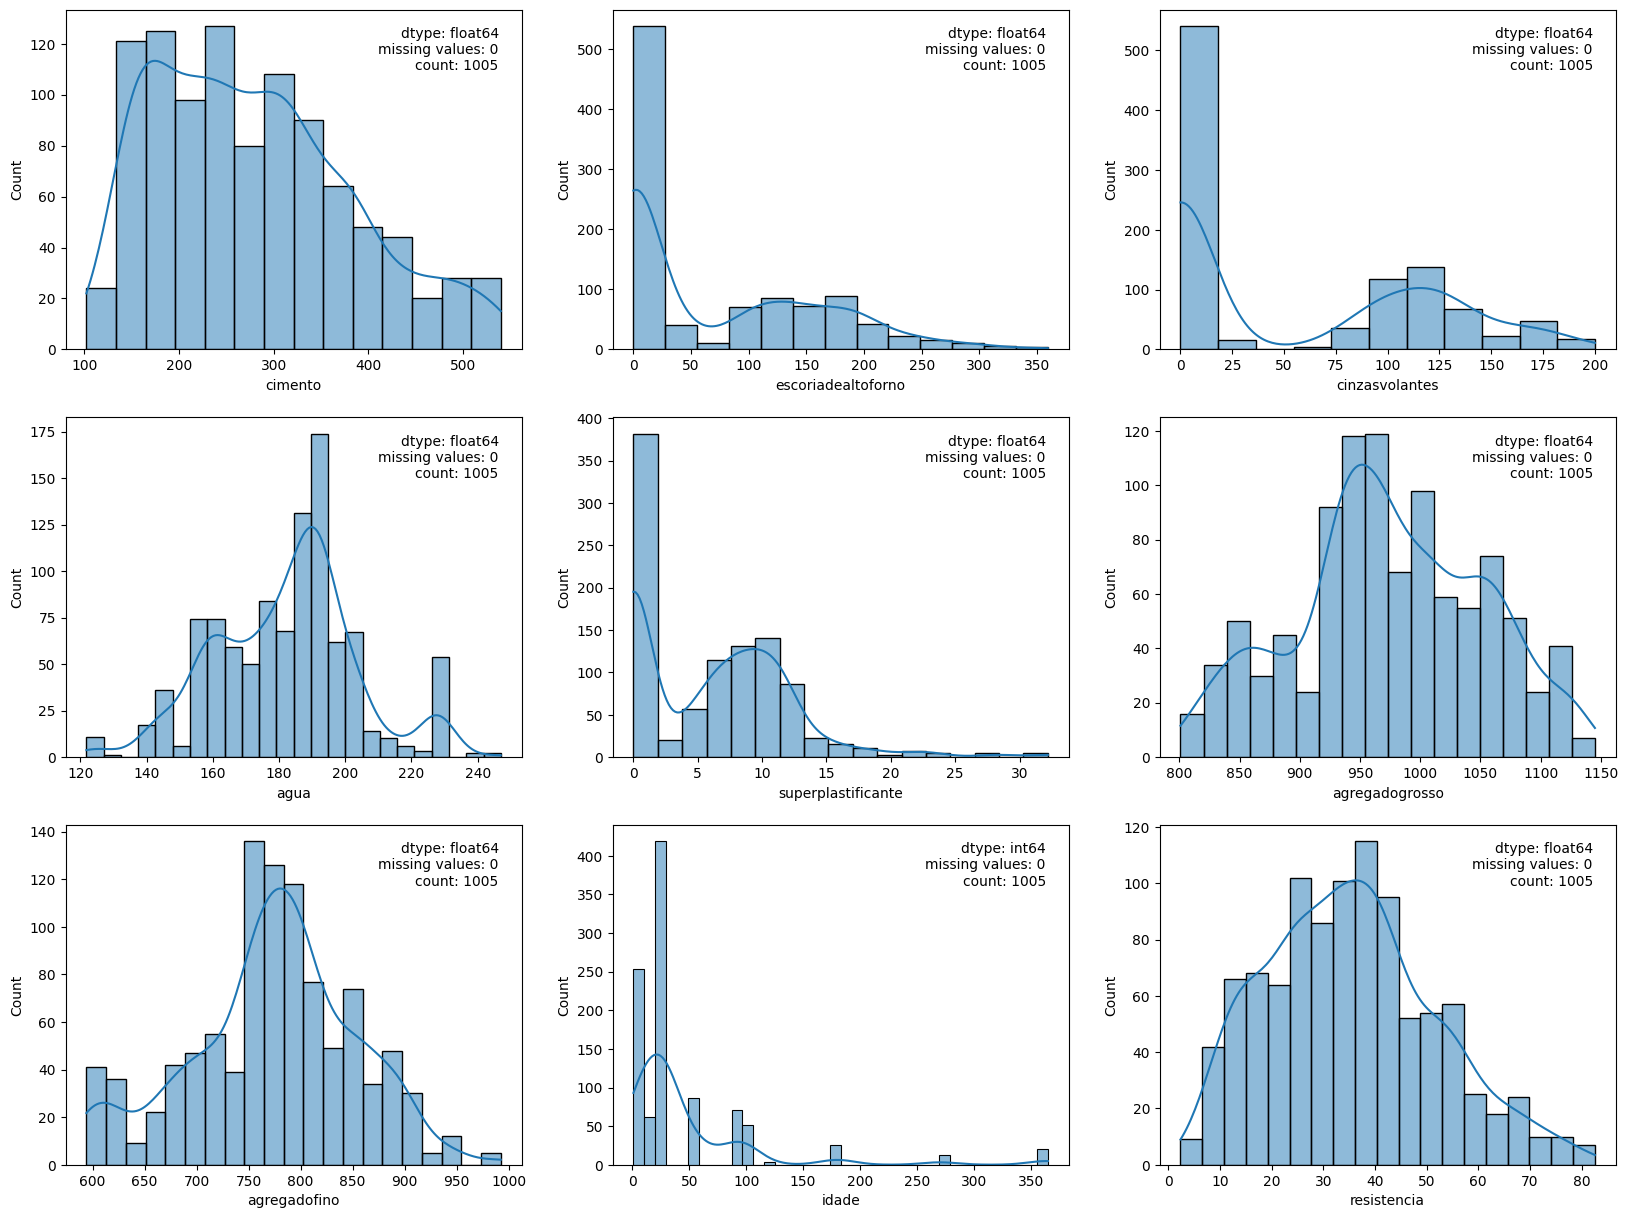

In [58]:
columns = df.columns
figure, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))

for i, column in enumerate(columns):
    row = i // 3
    col = i % 3
    text = (f"dtype: {df[column].dtype}\n"
            f"missing values: {df[column].isnull().sum()}\n"
            f"count: {df[column].count()}")
    axes[row][col].text(0.95, 0.95, text, transform=axes[row][col].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df[column], ax=axes[row][col], kde=True)

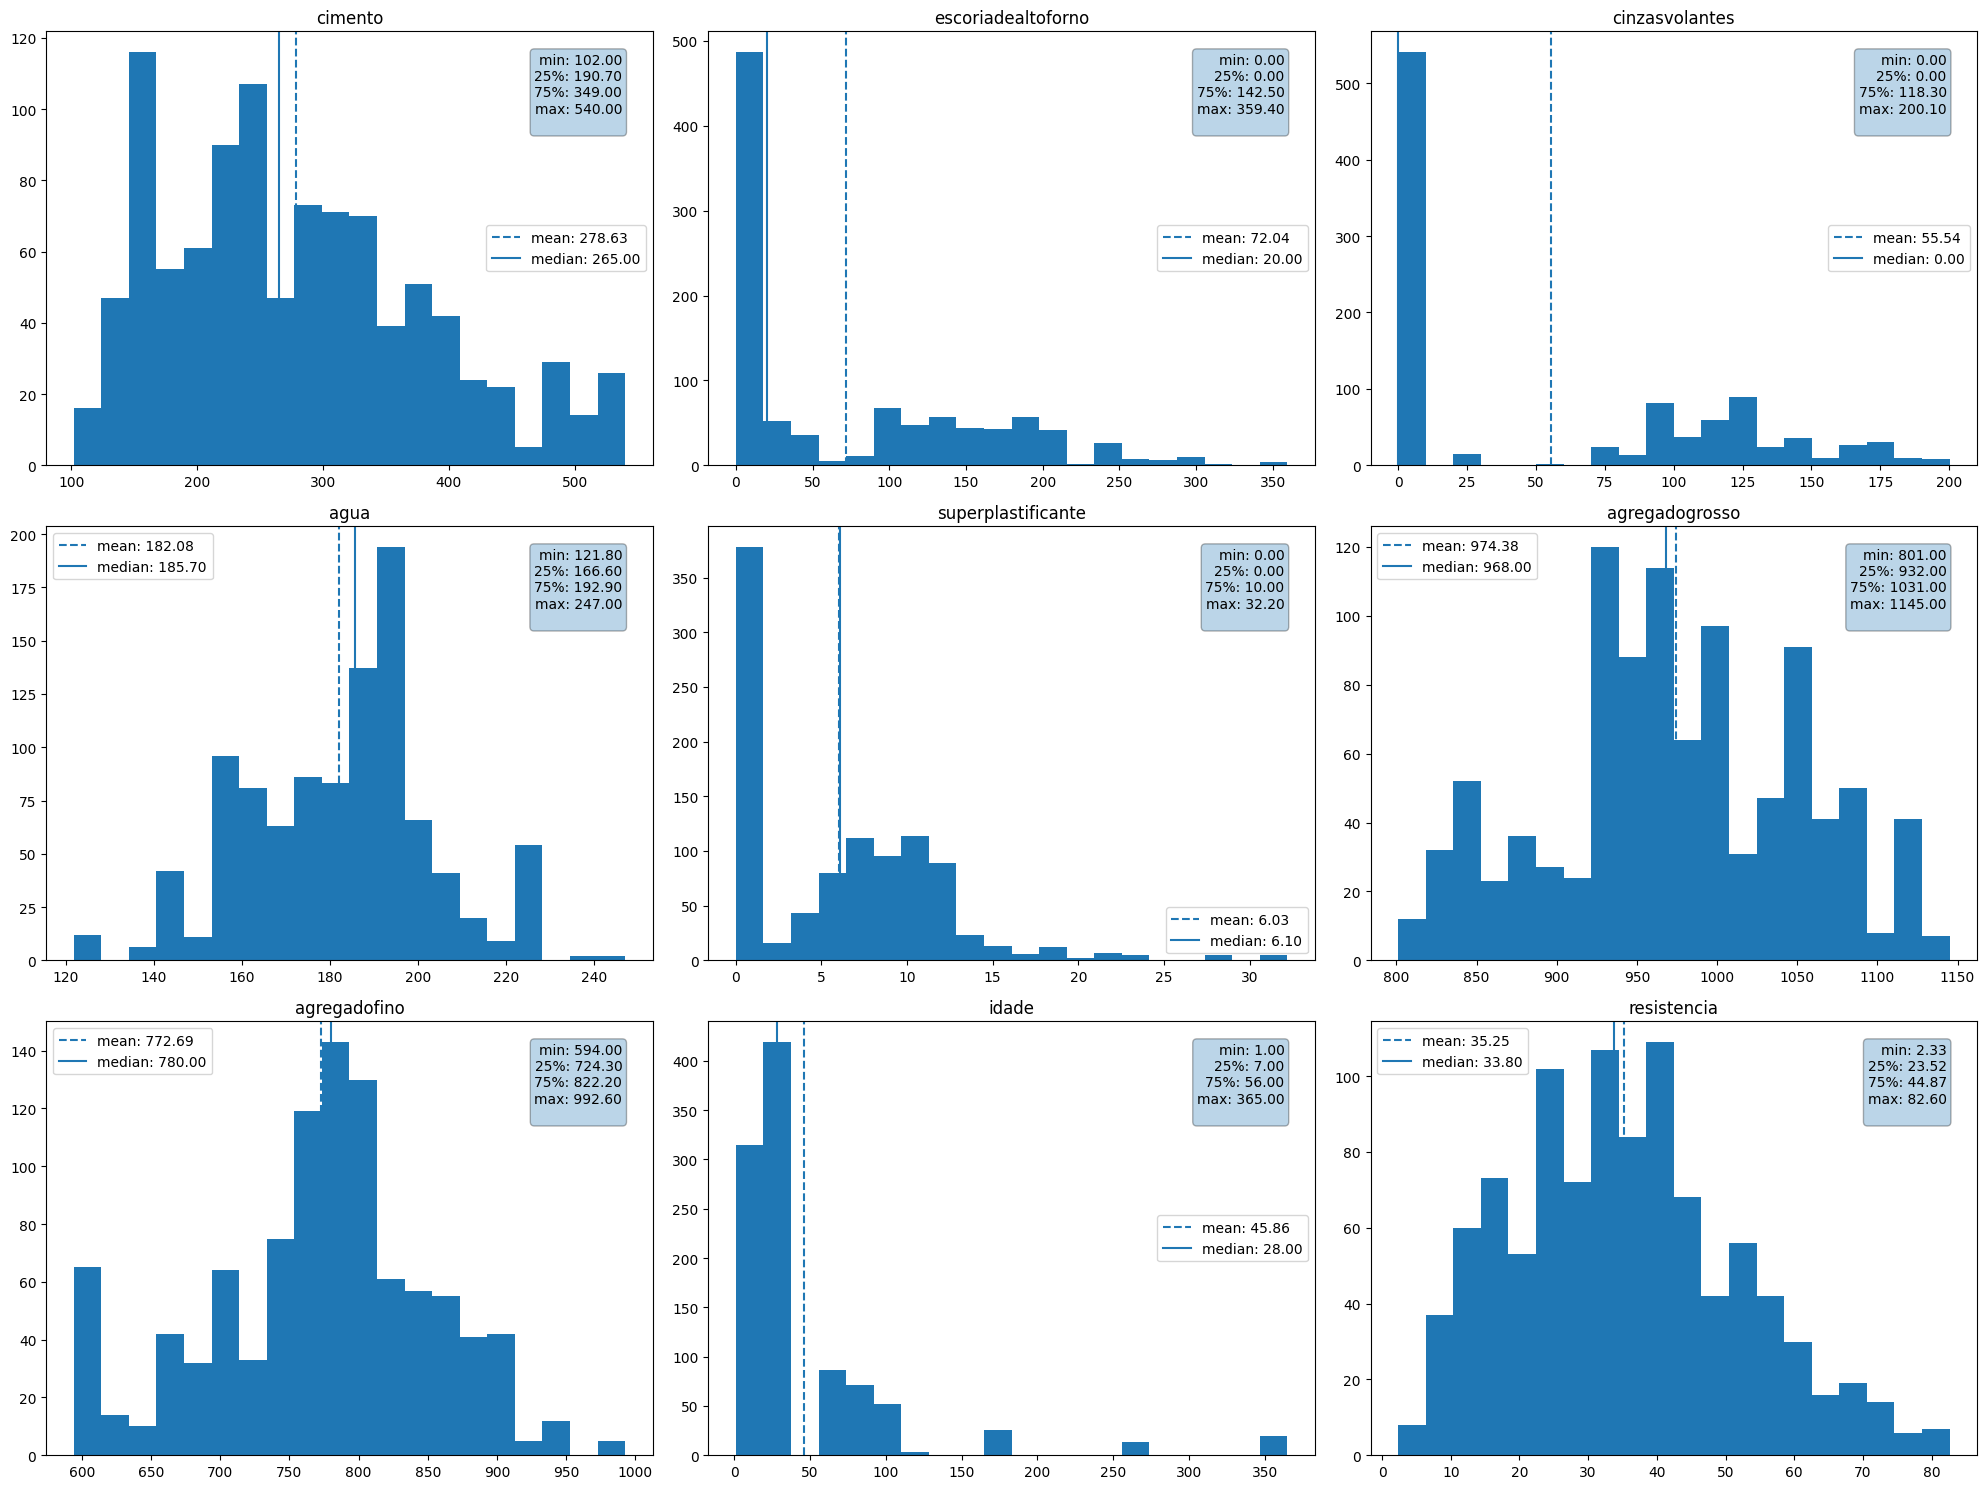

In [59]:
figure, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))

for i, column in enumerate(columns):
    ax = axes[i // 3, i % 3]
    data = df[column].dropna()
    
    ax.set_title(column)
    ax.hist(data, bins=20)
    
    stats = data.describe()
    
    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")
    
    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )
    
    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

## Ánalise de correlação entre features

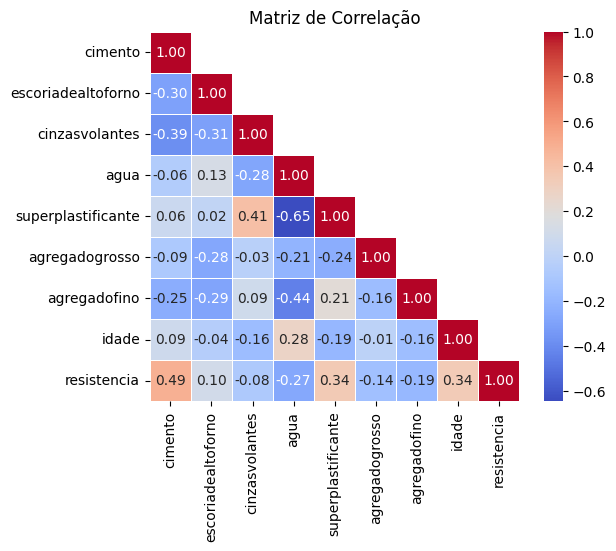

In [60]:
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", cbar=True,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 10}, square=True,
            mask=np.triu(corr, k=1))
plt.title("Matriz de Correlação")
plt.show()

In [61]:
df['bins'] = pd.qcut(df['resistencia'], q=10, duplicates='drop')

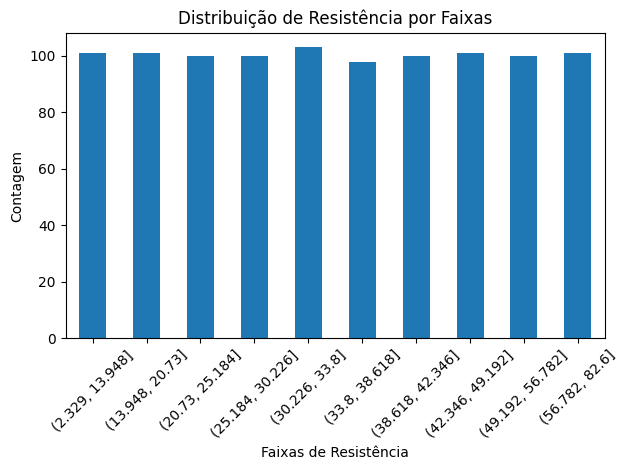

In [62]:
df['bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição de Resistência por Faixas')
plt.xlabel('Faixas de Resistência')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
df.to_pickle(os.path.join(dirpath, 'df_analise.pkl'))